In [15]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

In [16]:
# Apply SciencePlots style for ACL-quality publication figures
# Using 'science' with 'ieee' for proper column widths and professional styling
# plt.style.use(['science', 'ieee', 'grid', 'no-latex'])  # no-latex for faster rendering, remove if you have LaTeX
# Alternative if you have LaTeX installed: plt.style.use(['science', 'ieee', 'grid'])

# Set default figure parameters for publication quality
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'legend.title_fontsize': 10,
    'figure.titlesize': 13,
    'font.family': 'Arial',
})

# ============================================================================
# UNIFIED AESTHETICS CONFIGURATION FOR ALL PLOTS
# ============================================================================

# Color scheme - Paul Tol's colorblind-safe palette
PLOT_COLORS = {
    "4B": "#4477AA",      # Blue - colorblind safe
    "8B": "#CC6677",      # Red/Pink - colorblind safe
    "base": "#CC6677",    # Base color for single-color plots
}

# Unified styling constants
STYLE = {
    # Grid
    'grid_linestyle': '--',
    'grid_alpha': 0.4,
    'grid_linewidth': 0.5,

    # Spines
    'spine_linewidth': 2.0,
    'hide_top': True,
    'hide_right': True,

    # Bars
    'bar_edgecolor': 'black',
    'bar_linewidth': 0.5,
    'bar_alpha': 0.9,
    'bar_width': 0.75,

    # Text labels
    'value_label_fontsize': 8,
    'title_fontsize': 24,
    'title_fontweight': 'bold',
    'title_pad': 15,
    'axis_label_fontsize': 22,
    'axis_label_fontweight': 'bold',
    'tick_label_fontsize': 18,

    # Legend
    'legend_fontsize': 9,
    'legend_frameon': True,
    'legend_fancybox': False,
    'legend_shadow': False,
    'legend_framealpha': 1.0,
    'legend_edgecolor': 'black',
    'legend_frame_linewidth': 0.5,
    'legend_bbox_to_anchor': (0.5, 1.02),

    # Figure
    'fig_dpi': 600,
    'fig_facecolor': 'white',
    'fig_tight_rect': [0, 0, 1, 0.96],

    # Heatmap
    'heatmap_text_fontsize': 16,
    'heatmap_text_fontweight': 'bold',
    'heatmap_cbar_fontsize': 10,
    'heatmap_cbar_label_fontsize': 10,
    'heatmap_cbar_tick_fontsize': 14,
    'heatmap_cbar_tick_width': 0.5,
    'heatmap_cbar_tick_length': 3,
    'heatmap_cbar_outline_linewidth': 1.0,
    'heatmap_xlabel_fontsize': 15,
}

def apply_axis_styling(ax):
    """Apply unified axis styling to any axis"""
    ax.yaxis.grid(True, linestyle=STYLE['grid_linestyle'], 
                  alpha=STYLE['grid_alpha'], linewidth=STYLE['grid_linewidth'])
    ax.set_axisbelow(True)
    if STYLE['hide_top']:
        ax.spines['top'].set_visible(False)
    if STYLE['hide_right']:
        ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(STYLE['spine_linewidth'])
    ax.spines['bottom'].set_linewidth(STYLE['spine_linewidth'])

def apply_legend_styling(legend):
    """Apply unified legend styling"""
    legend.get_frame().set_linewidth(STYLE['legend_frame_linewidth'])

In [17]:
data = {
    "amazon": {
        "hit@1": np.array([
            [0.512, 0.541, 0.550, 0.553, 0.554],  # Agent 1 (bottom row)
            [0.540, 0.553, 0.556, 0.556, 0.556],  # Agent 2 (middle row)
            [0.550, 0.559, 0.560, 0.559, 0.558],  # Agent 3 (top row)
        ]),
        "recall@20": np.array([
            [0.502, 0.531, 0.540, 0.545, 0.546],  # Agent 1 (bottom row)
            [0.563, 0.582, 0.588, 0.588, 0.588],  # Agent 2 (middle row)
            [0.588, 0.602, 0.606, 0.606, 0.606],  # Agent 3 (top row)
        ]),
        "latency": np.array([
            [7.70, 7.90, 7.98, 8.02, 8.04],       # Agent 1 (bottom row)
            [8.73, 8.99, 9.12, 9.17, 9.19],       # Agent 2 (middle row)
            [9.22, 9.52, 9.67, 9.74, 9.76],       # Agent 3 (top row)
        ]),
    },
    "mag": {
        "hit@1": np.array([
            [0.469, 0.590, 0.662, 0.689, 0.694],  # Agent 1 (bottom row)
            [0.535, 0.650, 0.704, 0.719, 0.721],  # Agent 2 (middle row)
            [0.567, 0.674, 0.717, 0.731, 0.734],  # Agent 3 (top row)
        ]),
        "recall@20": np.array([
            [0.515, 0.646, 0.717, 0.747, 0.752],  # Agent 1 (bottom row)
            [0.601, 0.729, 0.791, 0.813, 0.817],  # Agent 2 (middle row)
            [0.642, 0.770, 0.823, 0.839, 0.843],  # Agent 3 (top row)
        ]),
        "latency": np.array([
            [6.86, 7.93, 8.78, 9.08, 9.14],       # Agent 1 (bottom row)
            [9.04, 10.27, 11.21, 11.63, 11.76],   # Agent 2 (middle row)
            [9.72, 11.99, 12.98, 13.48, 13.63],   # Agent 3 (top row)
        ]),
    },
    "prime": {
        "hit@1": np.array([
            [0.258, 0.361, 0.415, 0.438, 0.441],  # Agent 1 (bottom row)
            [0.316, 0.414, 0.451, 0.460, 0.461],  # Agent 2 (middle row)
            [0.344, 0.439, 0.473, 0.480, 0.483],  # Agent 3 (top row)
        ]),
        "recall@20": np.array([
            [0.362, 0.489, 0.550, 0.576, 0.581],  # Agent 1 (bottom row)
            [0.455, 0.583, 0.634, 0.653, 0.657],  # Agent 2 (middle row)
            [0.499, 0.626, 0.670, 0.690, 0.693],  # Agent 3 (top row)
        ]),
        "latency": np.array([
            [7.16, 8.34, 9.12, 9.67, 9.85],       # Agent 1 (bottom row)
            [8.28, 9.69, 10.67, 11.37, 11.69],    # Agent 2 (middle row)
            [8.94, 10.40, 11.48, 12.33, 12.74],   # Agent 3 (top row)
        ]),
    },
}

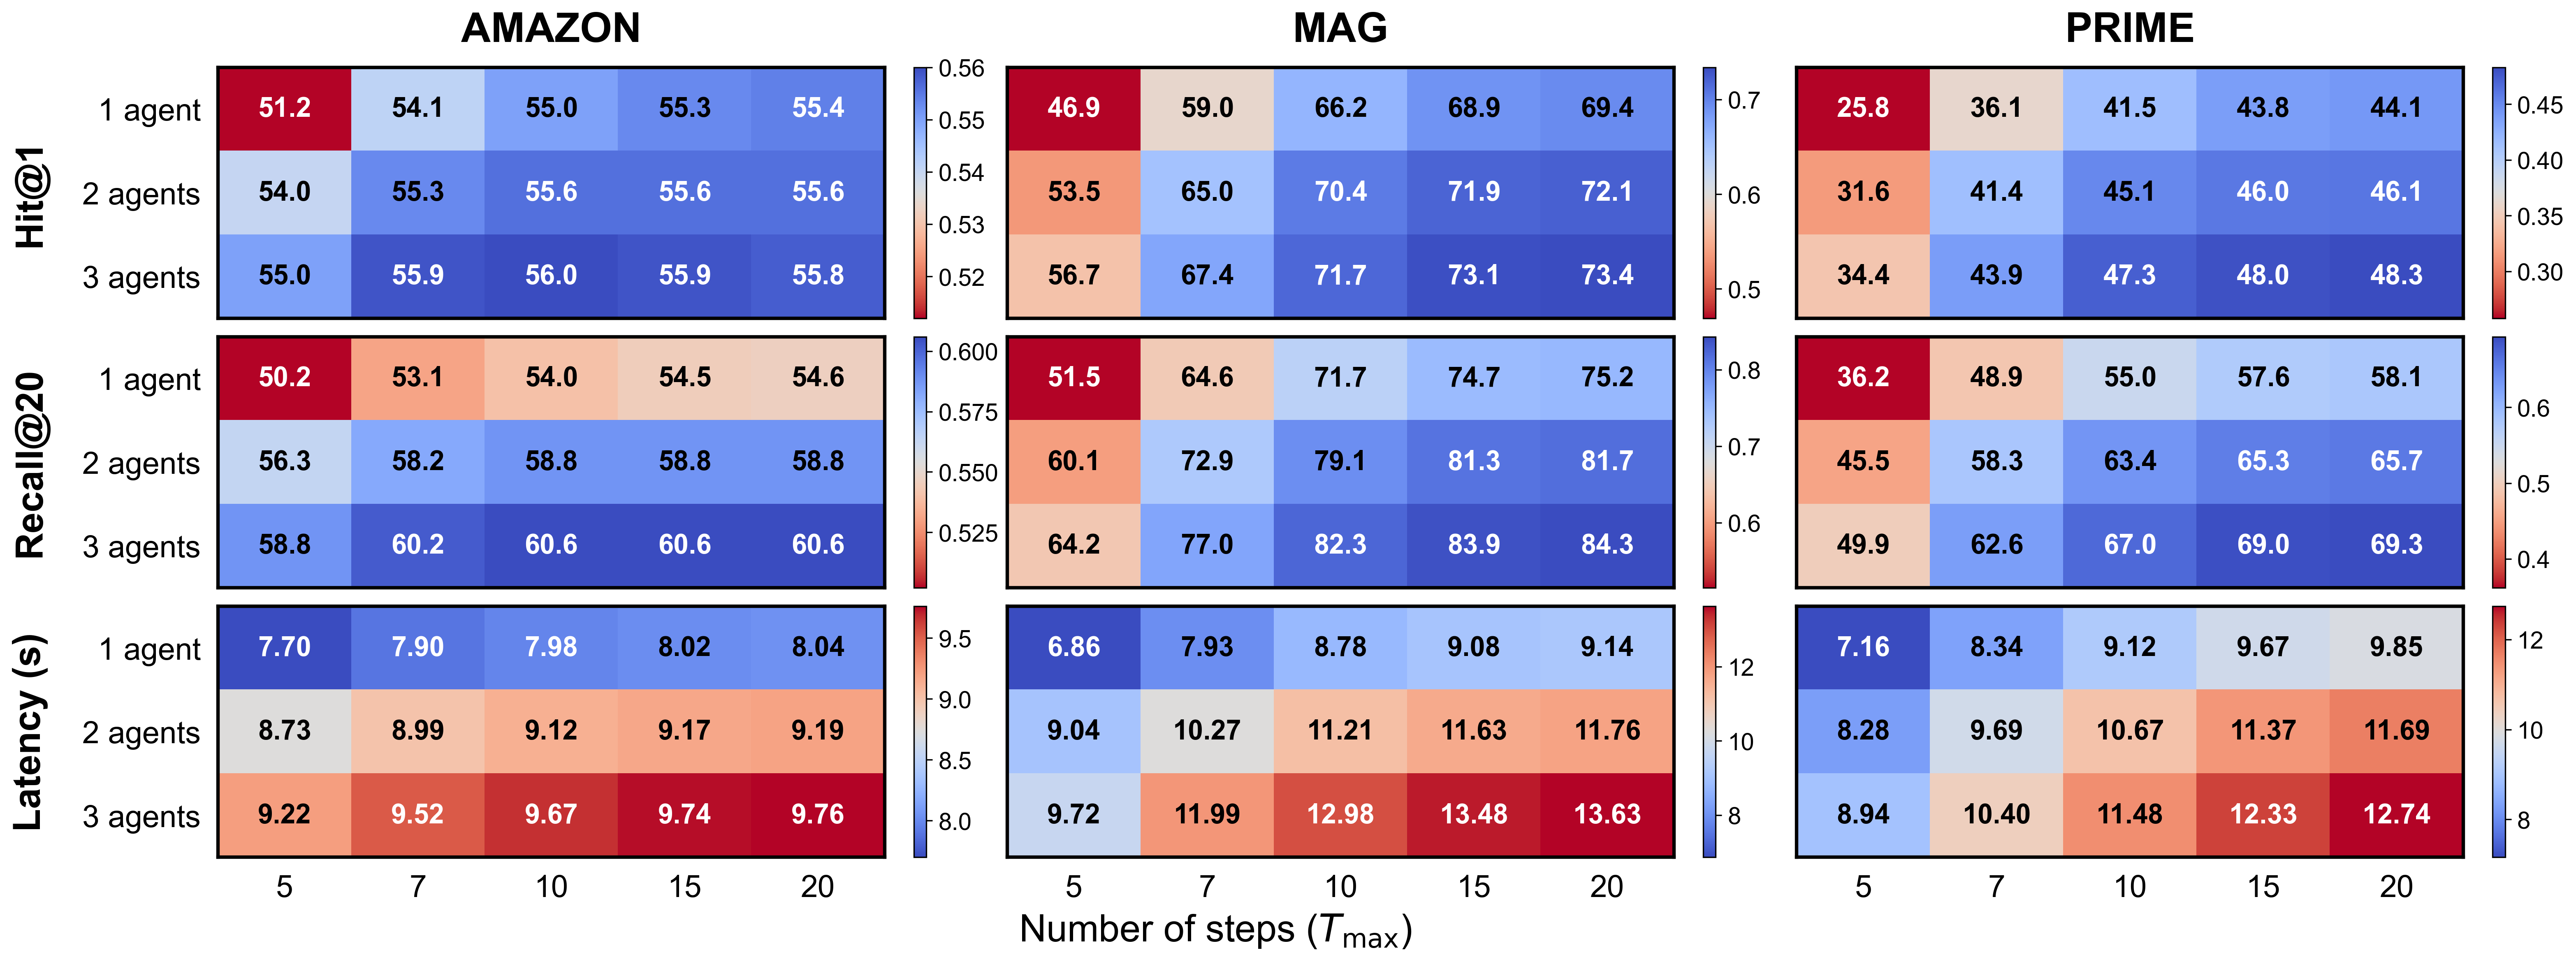

In [21]:
def figure_2():
    # Define custom hex palette
    # hex_colors = ["#eaac8b", "#e56b6f", "#b56576", "#6d597a", "#355070"][::-1]
    # hex_colors = ["#006d77", "#83c5be", "#edf6f9", "#ffddd2", "#e29578"][::-1]
    # hex_colors = ["#1E1E1E", "#A51C30", "#198F51", "#293352", "#A8C3E2", "#F3C11B"]
    # hex_colors = ["#198F51", "#A51C30"]
    # hex_colors = ["#F3C11B", "#A8C3E2", "#293352"]
    hex_colors = ["#A51C30", "#A8C3E2", "#293352"][::-1]
    
    # Create the Colormap
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("sunset", hex_colors)
    custom_cmap_r = custom_cmap.reversed()

    # Create coolwarm colormap
    custom_cmap = plt.cm.coolwarm
    custom_cmap_r = custom_cmap.reversed()

    def get_text_color(bg_color):
        """Determines if text should be white or black based on background luminance."""
        # bg_color is an (R, G, B, A) tuple from the colormap
        r, g, b, _ = bg_color
        # Calculate luminance
        luminance = 0.299 * r + 0.587 * g + 0.114 * b
        return "white" if luminance < 0.53 else "black"

    def heatmap_with_numbers(
        ax, matrix, xticks, yticks, title, invert=False, format_as_percent=False
    ):
        # Choose cmap based on whether we want to invert the visual logic
        cmap_final = custom_cmap if invert else custom_cmap_r

        im = ax.imshow(
            matrix, aspect="auto", origin="upper",
            cmap=cmap_final, interpolation='nearest'
        )

        ax.set_xticks(np.arange(len(xticks)))
        ax.set_xticklabels(xticks, fontsize=STYLE['tick_label_fontsize'])
        ax.set_yticks(np.arange(len(yticks)))
        ax.set_yticklabels(yticks, fontsize=STYLE['tick_label_fontsize'])

        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(STYLE['spine_linewidth'])

        if title:
            ax.set_title(title, fontsize=STYLE['title_fontsize'], 
                        fontweight=STYLE['title_fontweight'], pad=STYLE['title_pad'])

        nrows, ncols = matrix.shape
        
        # Normalize matrix to get colors for text contrast calculation
        norm = plt.Normalize(vmin=np.nanmin(matrix), vmax=np.nanmax(matrix))
        
        for i in range(nrows):
            for j in range(ncols):
                val = matrix[i, j]
                if np.isnan(val): continue
                
                text = f"{val * 100:.1f}" if format_as_percent else f"{val:.2f}"
                
                # Determine text color based on the actual color of the cell
                cell_color = cmap_final(norm(val))
                text_color = get_text_color(cell_color)

                ax.text(j, i, text, ha="center", va="center",
                        fontsize=STYLE['heatmap_text_fontsize'],
                        fontweight=STYLE['heatmap_text_fontweight'],
                        color=text_color)

        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=STYLE['heatmap_cbar_tick_fontsize'])
        return im
    
    graph_names = ["amazon", "mag", "prime"]
    metrics = ["hit@1", "recall@20", "latency"]
    metric_labels = ["Hit@1", "Recall@20", "Latency (s)"]
    num_agents_grid = ['1 agent', '2 agents', '3 agents']
    t_max_grid = [5, 7, 10, 15, 20]

    fig, axes = plt.subplots(len(metrics), len(graph_names), figsize=(22, 8), sharex=True, sharey=True)

    for m_idx, metric_key in enumerate(metrics):
        for g_idx, graph_name in enumerate(graph_names):
            ax = axes[m_idx, g_idx]
            matrix = data[graph_name][metric_key]
            
            heatmap_with_numbers(
                ax, matrix, xticks=t_max_grid, yticks=num_agents_grid,
                title=graph_name.upper() if m_idx == 0 else "", 
                invert=(metric_key == "latency"), format_as_percent=(metric_key != "latency")
            )

            if g_idx == 0:
                ax.set_ylabel(f"{metric_labels[m_idx]}", 
                              fontsize=STYLE['axis_label_fontsize'], 
                              fontweight='bold',
                              labelpad=20)
                ax.tick_params(axis='y', labelleft=True, pad=10)
            
            ax.tick_params(axis='x', pad=10)
            ax.tick_params(axis='both', which='both', length=0)

    fig.text(0.5, 0.01, r"Number of steps ($T_{\max}$)", ha='center', fontsize=STYLE['axis_label_fontsize'])
    plt.tight_layout(rect=[0.05, 0.03, 1, 0.97])

    os.makedirs("../data/figures", exist_ok=True)
    plt.savefig("../data/figures/fig-2-compute.pdf", dpi=STYLE['fig_dpi'], bbox_inches="tight")
    plt.show()

figure_2()